# Intermediate-Width Wafer Map CNN

This notebook repeats the complete controlled experiment suite using an intermediate-width CNN.

The convolutional widths are reduced from `32 → 64 → 128` to `24 → 48 → 96`, while the dense representation is reduced from 128 to 96 units. This architecture contains approximately 56% of the parameters of the full model and substantially reduces convolutional computation without halving the feature extractor outright.

The data protocol is unchanged. A stratified 65%/15%/20% split is created from the full labeled dataset. The 3,000-sample cap is applied only to the training partition and independently for each class. Validation Macro F1 guides checkpointing, early stopping, and model selection. The large, naturally distributed test set is evaluated only after every configuration has been fixed.

Arbitrary-angle rotation is intentionally retained as a didactic experiment. Wafer maps contain discrete values, so interpolated rotations can create artificial intermediate values. The following safe-augmentation experiment isolates this effect.

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import os

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.optimizers import Adam, Nadam, RMSprop, SGD
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

In [ ]:
import sys
from pathlib import Path

def find_repository_root(start_path=None):
    current_path = (
        Path.cwd()
        if start_path is None
        else Path(start_path)
    ).resolve()

    for candidate in (current_path, *current_path.parents):
        has_project = (candidate / "project").is_dir()
        has_datasets = (candidate / "datasets").is_dir()

        if has_project and has_datasets:
            return candidate

    raise FileNotFoundError(
        "Repository root not found. Expected directories "
        "'project' and 'datasets' in the same location."
    )


REPO_ROOT = find_repository_root()
PROJECT_DIR = REPO_ROOT / "project"
DATASETS_DIR = REPO_ROOT / "datasets"

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

In [5]:
from utils import (
    build_optimized_model,
    build_intermediate_model,
    cap_indices_per_class,
    evaluate_classifier,
    make_macro_f1_callbacks,
    plot_confusion_matrix,
    plot_training_history,
    resize_wafer_maps,
    set_global_determinism,
    visualize_original_and_maps
)

## Configuration

The dataset path is the only project-specific setting. Checkpoints, split indices, and result tables are stored under `cnn_outputs_intermediate`.

In [6]:
DATASET_PATH = DATASETS_DIR / "Dataset.pkl"
OUTPUT_DIR = PROJECT_DIR / "cnn_outputs_intermediate"
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"

TARGET_SHAPE = (56, 56)
MAX_SAMPLES_PER_CLASS = 3000

TRAIN_FRACTION = 0.65
VALIDATION_FRACTION = 0.15
TEST_FRACTION = 0.20

BATCH_SIZE = 128
PREDICTION_BATCH_SIZE = 256
MAX_EPOCHS = 50

EXPECTED_CLASSES = [
    "center",
    "donut",
    "edge-loc",
    "edge-ring",
    "loc",
    "near-full",
    "none",
    "random",
    "scratch",
]

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

assert np.isclose(
    TRAIN_FRACTION + VALIDATION_FRACTION + TEST_FRACTION,
    1.0,
)

In [7]:
gpus = tf.config.list_physical_devices("GPU")

if gpus:
    try:
        tf.config.set_visible_devices(gpus[0], "GPU")
        tf.config.experimental.set_memory_growth(gpus[0], True)
        print(f"Using GPU: {gpus[0].name}")
    except RuntimeError as error:
        print(f"GPU configuration was already initialized: {error}")
else:
    print("No GPU detected. TensorFlow will use the CPU.")

set_global_determinism(SEED, clear_session=False)

Using GPU: /physical_device:GPU:0


## Dataset preparation

Only the nine documented wafer classes are retained. Empty or unsupported labels are excluded before encoding and splitting.

In [8]:
if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {DATASET_PATH.resolve()}. "
        "Update DATASET_PATH before running the notebook."
    )

df = pd.read_pickle(DATASET_PATH)

required_columns = {"waferMap", "failureType"}
missing_columns = required_columns.difference(df.columns)
if missing_columns:
    raise KeyError(f"Missing required columns: {sorted(missing_columns)}")

df = df[df["failureType"].isin(EXPECTED_CLASSES)].reset_index(drop=True)

missing_expected_classes = sorted(
    set(EXPECTED_CLASSES).difference(df["failureType"].unique())
)
if missing_expected_classes:
    raise ValueError(
        f"The dataset is missing expected classes: {missing_expected_classes}"
    )

print(f"Labeled wafer maps: {len(df):,}")
display(df.head())

Labeled wafer maps: 172,950


,waferMap,dieSize,lotName,waferIndex,trainTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,training,none
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,training,none
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,training,none
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,training,none
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,training,none


In [9]:
class_counts = (
    df["failureType"]
    .value_counts()
    .reindex(EXPECTED_CLASSES)
    .rename("Samples")
    .to_frame()
)
class_counts["Share (%)"] = class_counts["Samples"] / len(df) * 100

display(class_counts)

,Samples,Share (%)
failureType,,
center,4294,2.482798
donut,555,0.320902
edge-loc,5189,3.000289
edge-ring,9680,5.596993
loc,3593,2.077479
near-full,149,0.086152
none,147431,85.244868
random,866,0.500723
scratch,1193,0.689795


## Fixed train, validation, and test partitions

The split is stratified at image level. The final test partition keeps its natural class distribution and is never capped. Samples removed by the training cap are left unused; they are not moved into validation or test.

A lot-level split would be preferable when the target is strict generalization to unseen manufacturing lots. This notebook keeps the agreed stratified image-level protocol so that every rare class is represented in all three partitions.

In [10]:
encoder = LabelEncoder()
y_all = encoder.fit_transform(df["failureType"])
class_names = encoder.classes_
num_classes = len(class_names)
all_indices = np.arange(len(df), dtype=np.int64)

train_validation_indices, test_indices = train_test_split(
    all_indices,
    test_size=TEST_FRACTION,
    random_state=SEED,
    stratify=y_all,
)

validation_share_within_train_validation = (
    VALIDATION_FRACTION / (TRAIN_FRACTION + VALIDATION_FRACTION)
)

train_pool_indices, validation_indices = train_test_split(
    train_validation_indices,
    test_size=validation_share_within_train_validation,
    random_state=SEED,
    stratify=y_all[train_validation_indices],
)

train_indices = cap_indices_per_class(
    train_pool_indices,
    labels=y_all,
    max_samples_per_class=MAX_SAMPLES_PER_CLASS,
    seed=SEED,
)

assert len(np.intersect1d(train_indices, validation_indices)) == 0
assert len(np.intersect1d(train_indices, test_indices)) == 0
assert len(np.intersect1d(validation_indices, test_indices)) == 0
assert set(train_indices).issubset(set(train_pool_indices))
assert np.bincount(
    y_all[train_indices],
    minlength=num_classes,
).max() <= MAX_SAMPLES_PER_CLASS

np.savez_compressed(
    OUTPUT_DIR / "split_indices.npz",
    train_pool_indices=train_pool_indices,
    train_indices=train_indices,
    validation_indices=validation_indices,
    test_indices=test_indices,
)

print(f"Training pool before cap: {len(train_pool_indices):,}")
print(f"Training set after cap:   {len(train_indices):,}")
print(f"Validation set:           {len(validation_indices):,}")
print(f"Large test set:           {len(test_indices):,}")

Training pool before cap: 112,417
Training set after cap:   15,923
Validation set:           25,943
Large test set:           34,590


In [11]:
def distribution_for(indices, column_name):
    counts = np.bincount(y_all[indices], minlength=num_classes)
    return pd.Series(counts, index=class_names, name=column_name)


split_distribution = pd.concat(
    [
        distribution_for(train_pool_indices, "Training pool"),
        distribution_for(train_indices, "Training after cap"),
        distribution_for(validation_indices, "Validation"),
        distribution_for(test_indices, "Large test"),
    ],
    axis=1,
)

display(split_distribution)

,Training pool,Training after cap,Validation,Large test
center,2791,2791,644,859
donut,361,361,83,111
edge-loc,3372,3000,779,1038
edge-ring,6292,3000,1452,1936
loc,2336,2336,539,718
near-full,97,97,22,30
none,95830,3000,22115,29486
random,563,563,130,173
scratch,775,775,179,239


## Intermediate architecture

The intermediate model uses 24, 48, and 96 convolutional filters, followed by a 96-unit dense layer. The cell below calculates the parameter reduction directly from the two model-building functions.

Both temporary models are discarded immediately after the comparison. Every trained experiment is still created from a freshly reset random state.

In [12]:
set_global_determinism(SEED, clear_session=True)

full_reference_model = build_optimized_model(
    use_he=True,
    use_l2=True,
    optimizer="adam",
    input_shape=(*TARGET_SHAPE, 1),
    num_classes=num_classes,
)

intermediate_reference_model = build_intermediate_model(
    use_he=True,
    use_l2=True,
    optimizer="adam",
    input_shape=(*TARGET_SHAPE, 1),
    num_classes=num_classes,
)

full_parameter_count = full_reference_model.count_params()
intermediate_parameter_count = (
    intermediate_reference_model.count_params()
)
parameter_reduction = (
    1
    - intermediate_parameter_count
    / full_parameter_count
) * 100

print(f"Full model parameters:         {full_parameter_count:,}")
print(
    "Intermediate model parameters: "
    f"{intermediate_parameter_count:,}"
)
print(f"Parameter reduction:           {parameter_reduction:.2f}%")

intermediate_reference_model.summary()

del full_reference_model
del intermediate_reference_model
tf.keras.backend.clear_session()
set_global_determinism(SEED, clear_session=False)

Full model parameters:         897,673
Intermediate model parameters: 505,449
Parameter reduction:           43.69%
Model: "Intermediate_Wafer_CNN"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 normalize_discrete_values (  (None, 56, 56, 1)        0         
 Rescaling)                                                      
                                                                 
 conv_layer_1 (Conv2D)       (None, 56, 56, 24)        240       
                                                                 
 batch_norm_1 (BatchNormaliz  (None, 56, 56, 24)       96        
 ation)                                                          
                                                                 
 max_pool_1 (MaxPooling2D)   (None, 28, 28, 24)        0         
                                                                 
 conv_layer_2 (Conv2D)       (None, 28, 28, 48)        10416

## Resizing

Nearest-neighbor interpolation preserves the discrete wafer-map states. The arrays remain unsigned integers with values 0, 1, and 2. Normalization to 0, 0.5, and 1 is performed inside the model, avoiding large duplicated floating-point arrays.

In [13]:
X_train = resize_wafer_maps(
    df.iloc[train_indices],
    target_shape=TARGET_SHAPE,
)
X_validation = resize_wafer_maps(
    df.iloc[validation_indices],
    target_shape=TARGET_SHAPE,
)
X_test = resize_wafer_maps(
    df.iloc[test_indices],
    target_shape=TARGET_SHAPE,
)

y_train = y_all[train_indices]
y_validation = y_all[validation_indices]
y_test = y_all[test_indices]

y_train_categorical = to_categorical(
    y_train,
    num_classes=num_classes,
)
y_validation_categorical = to_categorical(
    y_validation,
    num_classes=num_classes,
)

print(f"Training features:   {X_train.shape}, {X_train.dtype}")
print(f"Validation features: {X_validation.shape}, {X_validation.dtype}")
print(f"Test features:       {X_test.shape}, {X_test.dtype}")
print(f"Observed training pixel values: {np.unique(X_train)}")

Resizing 15,923 wafer maps to (56, 56)...


  0%|          | 0/15923 [00:00<?, ?it/s]

Resizing 25,943 wafer maps to (56, 56)...


  0%|          | 0/25943 [00:00<?, ?it/s]

Resizing 34,590 wafer maps to (56, 56)...


  0%|          | 0/34590 [00:00<?, ?it/s]

Training features:   (15923, 56, 56, 1), uint8
Validation features: (25943, 56, 56, 1), uint8
Test features:       (34590, 56, 56, 1), uint8
Observed training pixel values: [0 1 2]


## Experimental protocol

Every model starts from the same random seed. Checkpointing and early stopping are based on validation Macro F1, which is the primary model-selection metric. The learning-rate scheduler monitors validation loss. Aggregate validation metrics are computed after loading the checkpoint with the best validation Macro F1.

The test set is not evaluated anywhere in the following architecture and optimizer experiments.

In [14]:
models = {}
histories = {}
checkpoints = {}
validation_records = []
validation_reports = {}
validation_confusion_matrices = {}


def register_validation_result(
    model_name,
    model,
    history,
    checkpoint_path,
):
    model.load_weights(checkpoint_path)

    metrics, report, matrix, _ = evaluate_classifier(
        model,
        X_validation,
        y_validation,
        class_names,
        batch_size=PREDICTION_BATCH_SIZE,
    )

    models[model_name] = model
    histories[model_name] = history
    checkpoints[model_name] = checkpoint_path
    validation_records.append({"Model": model_name, **metrics})
    validation_reports[model_name] = report
    validation_confusion_matrices[model_name] = matrix

    formatted = {
        name: f"{value * 100:.2f}%"
        for name, value in metrics.items()
    }
    display(pd.DataFrame([formatted], index=[model_name]))

## Baseline CNN

The intermediate baseline uses Glorot initialization, Adam, no augmentation, and no L2 regularization.

In [15]:
set_global_determinism(SEED)

baseline_name = "Intermediate — Baseline"
baseline_checkpoint = CHECKPOINT_DIR / "intermediate_baseline.weights.h5"

model_baseline = build_intermediate_model(
    use_he=False,
    use_l2=False,
    optimizer="adam",
    input_shape=(*TARGET_SHAPE, 1),
    num_classes=num_classes,
)

history_baseline = model_baseline.fit(
    X_train,
    y_train_categorical,
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_validation, y_validation_categorical),
    callbacks=make_macro_f1_callbacks(
        X_validation,
        y_validation,
        baseline_checkpoint,
        batch_size=PREDICTION_BATCH_SIZE,
    ),
    shuffle=True,
    verbose=1,
)

register_validation_result(
    baseline_name,
    model_baseline,
    history_baseline,
    baseline_checkpoint,
)

Epoch 1/50
125/125 [==============================] - ETA: 0s - loss: 1.4610 - accuracy: 0.4885 — val_macro_f1: 0.0015 — val_balanced_accuracy: 0.1111
Saved new best Macro F1 checkpoint at epoch 1.
125/125 [==============================] - 6s 34ms/step - loss: 1.4610 - accuracy: 0.4885 - val_loss: 15.2449 - val_accuracy: 0.0069 - val_macro_f1: 0.0015 - val_balanced_accuracy: 0.1111 - lr: 0.0010
Epoch 2/50
121/125 [============================>.] - ETA: 0s - loss: 1.0056 - accuracy: 0.6255 — val_macro_f1: 0.0935 — val_balanced_accuracy: 0.1826
Saved new best Macro F1 checkpoint at epoch 2.
125/125 [==============================] - 3s 27ms/step - loss: 1.0056 - accuracy: 0.6260 - val_loss: 11.9839 - val_accuracy: 0.0248 - val_macro_f1: 0.0935 - val_balanced_accuracy: 0.1826 - lr: 0.0010
Epoch 3/50
125/125 [==============================] - ETA: 0s - loss: 0.8793 - accuracy: 0.6747 — val_macro_f1: 0.1766 — val_balanced_accuracy: 0.2603
Saved new best Macro F1 checkpoint at epoch 3.
125/

,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1
Intermediate — Baseline,95.74%,81.31%,79.85%,81.31%,80.30%


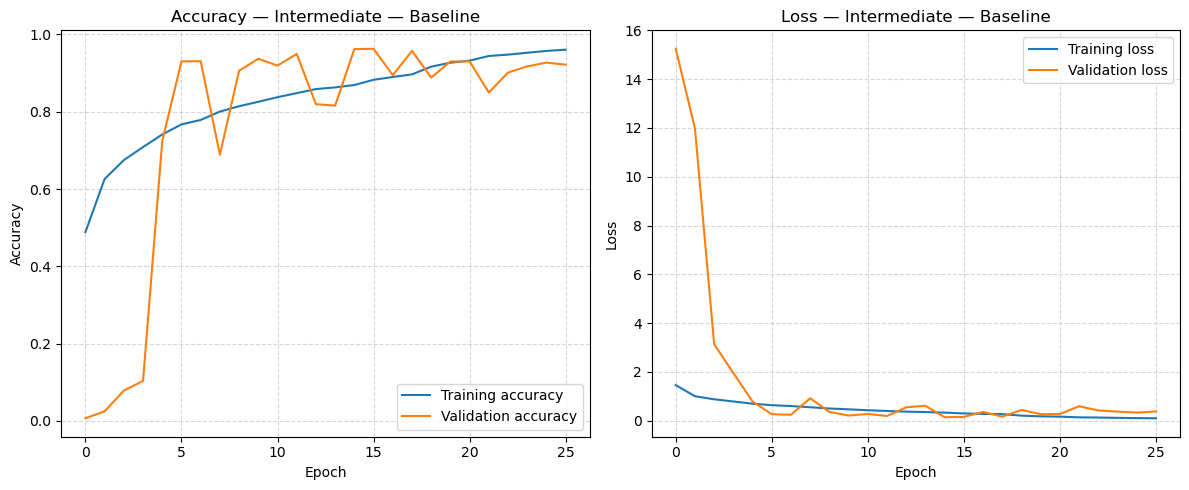

In [16]:
plot_training_history(history_baseline, baseline_name)

## He initialization

This experiment changes only the kernel initializer. All other training choices remain identical to the baseline.

In [17]:
set_global_determinism(SEED)

he_name = "Intermediate — He initialization"
he_checkpoint = CHECKPOINT_DIR / "intermediate_he_initialization.weights.h5"

model_he = build_intermediate_model(
    use_he=True,
    use_l2=False,
    optimizer="adam",
    input_shape=(*TARGET_SHAPE, 1),
    num_classes=num_classes,
)

history_he = model_he.fit(
    X_train,
    y_train_categorical,
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_validation, y_validation_categorical),
    callbacks=make_macro_f1_callbacks(
        X_validation,
        y_validation,
        he_checkpoint,
        batch_size=PREDICTION_BATCH_SIZE,
    ),
    shuffle=True,
    verbose=1,
)

register_validation_result(
    he_name,
    model_he,
    history_he,
    he_checkpoint,
)

Epoch 1/50
124/125 [============================>.] - ETA: 0s - loss: 1.4630 - accuracy: 0.4842 — val_macro_f1: 0.1182 — val_balanced_accuracy: 0.3352
Saved new best Macro F1 checkpoint at epoch 1.
125/125 [==============================] - 4s 30ms/step - loss: 1.4627 - accuracy: 0.4842 - val_loss: 1.9977 - val_accuracy: 0.0607 - val_macro_f1: 0.1182 - val_balanced_accuracy: 0.3352 - lr: 0.0010
Epoch 2/50
122/125 [============================>.] - ETA: 0s - loss: 1.0180 - accuracy: 0.6103 — val_macro_f1: 0.1771 — val_balanced_accuracy: 0.3990
Saved new best Macro F1 checkpoint at epoch 2.
125/125 [==============================] - 3s 25ms/step - loss: 1.0168 - accuracy: 0.6103 - val_loss: 2.1038 - val_accuracy: 0.1556 - val_macro_f1: 0.1771 - val_balanced_accuracy: 0.3990 - lr: 0.0010
Epoch 3/50
124/125 [============================>.] - ETA: 0s - loss: 0.9021 - accuracy: 0.6567 — val_macro_f1: 0.4989 — val_balanced_accuracy: 0.5403
Saved new best Macro F1 checkpoint at epoch 3.
125/12

,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1
Intermediate — He initialization,91.57%,82.48%,71.76%,82.48%,75.27%


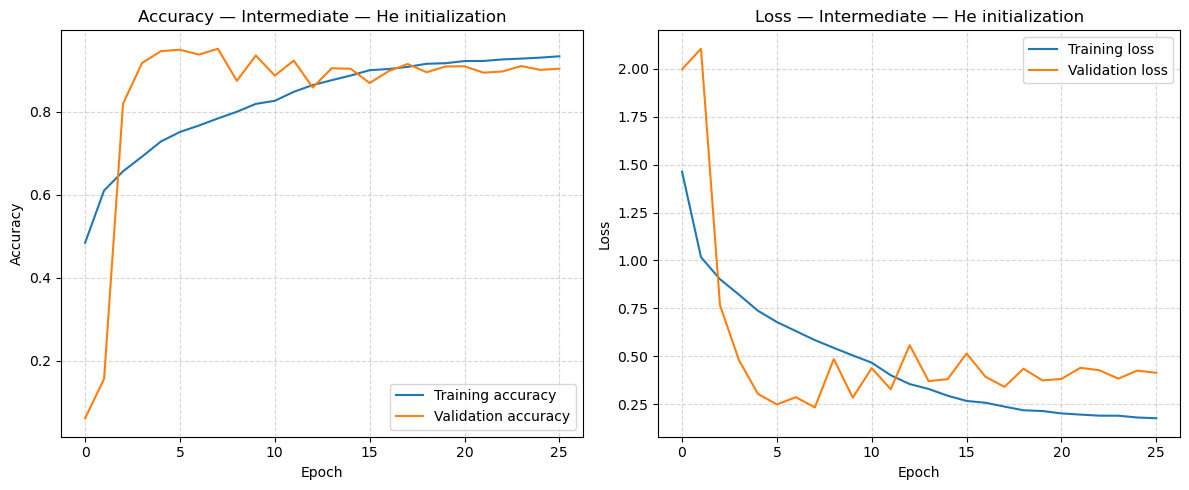

In [18]:
plot_training_history(history_he, he_name)

## Didactic experiment: arbitrary-angle rotations

Horizontal and vertical flips are combined with random rotations up to 72 degrees. This is intentionally retained as a problematic augmentation strategy.

The source maps contain discrete values. Arbitrary rotations require interpolation, which can introduce artificial intermediate values and blur narrow structures such as scratches. This experiment provides evidence for the report rather than a recommended preprocessing choice.

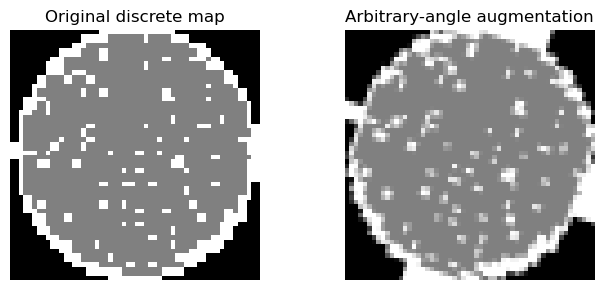

Original unique values: [0 1 2]
Augmented unique-value count: 678


In [19]:
set_global_determinism(SEED)

bad_augmentation = ImageDataGenerator(
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=72,
)

preview_iterator = bad_augmentation.flow(
    X_train[:1],
    y_train_categorical[:1],
    batch_size=1,
    shuffle=False,
    seed=SEED,
)
preview_image = next(preview_iterator)[0][0]

_, axes = plt.subplots(1, 2, figsize=(7, 3))
axes[0].imshow(np.squeeze(X_train[0]), cmap="gray")
axes[0].set_title("Original discrete map")
axes[1].imshow(np.squeeze(preview_image), cmap="gray")
axes[1].set_title("Arbitrary-angle augmentation")

for axis in axes:
    axis.axis("off")

plt.tight_layout()
plt.show()

print(f"Original unique values: {np.unique(X_train[0])}")
print(
    "Augmented unique-value count: "
    f"{len(np.unique(preview_image))}"
)

In [20]:
set_global_determinism(SEED)

bad_rotation_name = "Intermediate — He + arbitrary rotations"
bad_rotation_checkpoint = (
    CHECKPOINT_DIR / "intermediate_he_arbitrary_rotations.weights.h5"
)

model_bad_rotation = build_intermediate_model(
    use_he=True,
    use_l2=False,
    optimizer="adam",
    input_shape=(*TARGET_SHAPE, 1),
    num_classes=num_classes,
)

bad_augmentation = ImageDataGenerator(
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=72,
)

history_bad_rotation = model_bad_rotation.fit(
    bad_augmentation.flow(
        X_train,
        y_train_categorical,
        batch_size=BATCH_SIZE,
        shuffle=True,
        seed=SEED,
    ),
    epochs=MAX_EPOCHS,
    validation_data=(X_validation, y_validation_categorical),
    callbacks=make_macro_f1_callbacks(
        X_validation,
        y_validation,
        bad_rotation_checkpoint,
        batch_size=PREDICTION_BATCH_SIZE,
    ),
    verbose=1,
)

register_validation_result(
    bad_rotation_name,
    model_bad_rotation,
    history_bad_rotation,
    bad_rotation_checkpoint,
)

Epoch 1/50
125/125 [==============================] - ETA: 0s - loss: 1.4528 - accuracy: 0.4620 — val_macro_f1: 0.1187 — val_balanced_accuracy: 0.2965
Saved new best Macro F1 checkpoint at epoch 1.
125/125 [==============================] - 10s 80ms/step - loss: 1.4528 - accuracy: 0.4620 - val_loss: 2.5184 - val_accuracy: 0.0654 - val_macro_f1: 0.1187 - val_balanced_accuracy: 0.2965 - lr: 0.0010
Epoch 2/50
125/125 [==============================] - ETA: 0s - loss: 1.0650 - accuracy: 0.5950 — val_macro_f1: 0.4390 — val_balanced_accuracy: 0.6528
Saved new best Macro F1 checkpoint at epoch 2.
125/125 [==============================] - 9s 69ms/step - loss: 1.0650 - accuracy: 0.5950 - val_loss: 1.4781 - val_accuracy: 0.4627 - val_macro_f1: 0.4390 - val_balanced_accuracy: 0.6528 - lr: 0.0010
Epoch 3/50
125/125 [==============================] - ETA: 0s - loss: 0.9637 - accuracy: 0.6319 — val_macro_f1: 0.6066 — val_balanced_accuracy: 0.6162
Saved new best Macro F1 checkpoint at epoch 3.
125/1

,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1
Intermediate — He + arbitrary rotations,87.25%,71.05%,70.86%,71.05%,65.79%


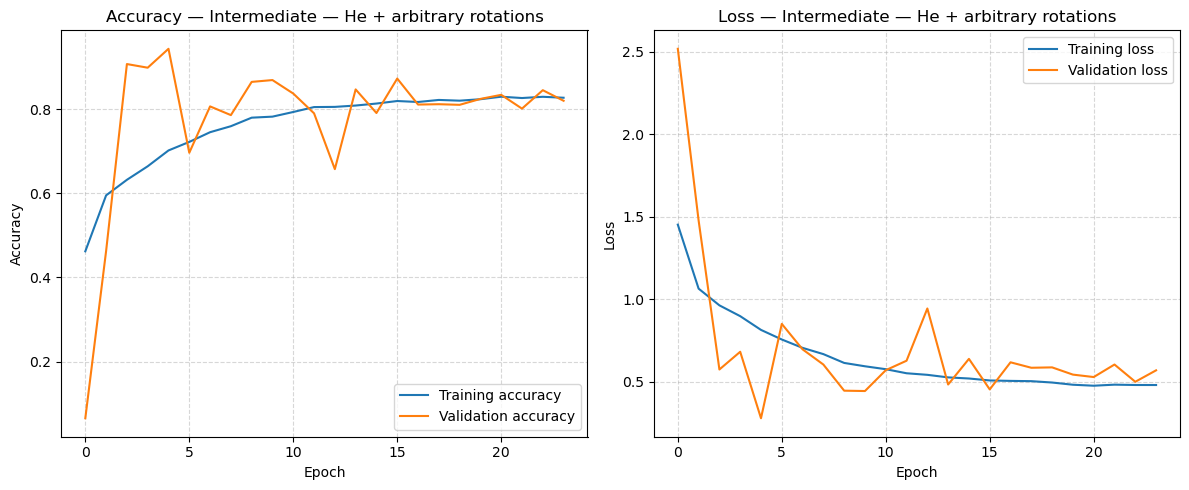

In [21]:
plot_training_history(
    history_bad_rotation,
    bad_rotation_name,
)

## Safe flip augmentation

This control experiment removes interpolated rotations while keeping horizontal and vertical flips. A flip changes spatial orientation without creating new pixel values.

In [22]:
set_global_determinism(SEED)

safe_flip_name = "Intermediate — He + safe flips"
safe_flip_checkpoint = CHECKPOINT_DIR / "intermediate_he_safe_flips.weights.h5"

model_safe_flip = build_intermediate_model(
    use_he=True,
    use_l2=False,
    optimizer="adam",
    input_shape=(*TARGET_SHAPE, 1),
    num_classes=num_classes,
)

safe_augmentation = ImageDataGenerator(
    horizontal_flip=True,
    vertical_flip=True,
)

history_safe_flip = model_safe_flip.fit(
    safe_augmentation.flow(
        X_train,
        y_train_categorical,
        batch_size=BATCH_SIZE,
        shuffle=True,
        seed=SEED,
    ),
    epochs=MAX_EPOCHS,
    validation_data=(X_validation, y_validation_categorical),
    callbacks=make_macro_f1_callbacks(
        X_validation,
        y_validation,
        safe_flip_checkpoint,
        batch_size=PREDICTION_BATCH_SIZE,
    ),
    verbose=1,
)

register_validation_result(
    safe_flip_name,
    model_safe_flip,
    history_safe_flip,
    safe_flip_checkpoint,
)

Epoch 1/50
122/125 [============================>.] - ETA: 0s - loss: 1.5924 - accuracy: 0.4339 — val_macro_f1: 0.0571 — val_balanced_accuracy: 0.2382
Saved new best Macro F1 checkpoint at epoch 1.
125/125 [==============================] - 4s 32ms/step - loss: 1.5846 - accuracy: 0.4348 - val_loss: 2.0128 - val_accuracy: 0.1013 - val_macro_f1: 0.0571 - val_balanced_accuracy: 0.2382 - lr: 0.0010
Epoch 2/50
122/125 [============================>.] - ETA: 0s - loss: 1.1540 - accuracy: 0.5646 — val_macro_f1: 0.3196 — val_balanced_accuracy: 0.4510
Saved new best Macro F1 checkpoint at epoch 2.
125/125 [==============================] - 4s 31ms/step - loss: 1.1524 - accuracy: 0.5658 - val_loss: 1.5755 - val_accuracy: 0.3118 - val_macro_f1: 0.3196 - val_balanced_accuracy: 0.4510 - lr: 0.0010
Epoch 3/50
124/125 [============================>.] - ETA: 0s - loss: 1.0436 - accuracy: 0.6058 — val_macro_f1: 0.4426 — val_balanced_accuracy: 0.5056
Saved new best Macro F1 checkpoint at epoch 3.
125/12

,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1
Intermediate — He + safe flips,93.13%,85.25%,73.07%,85.25%,77.60%


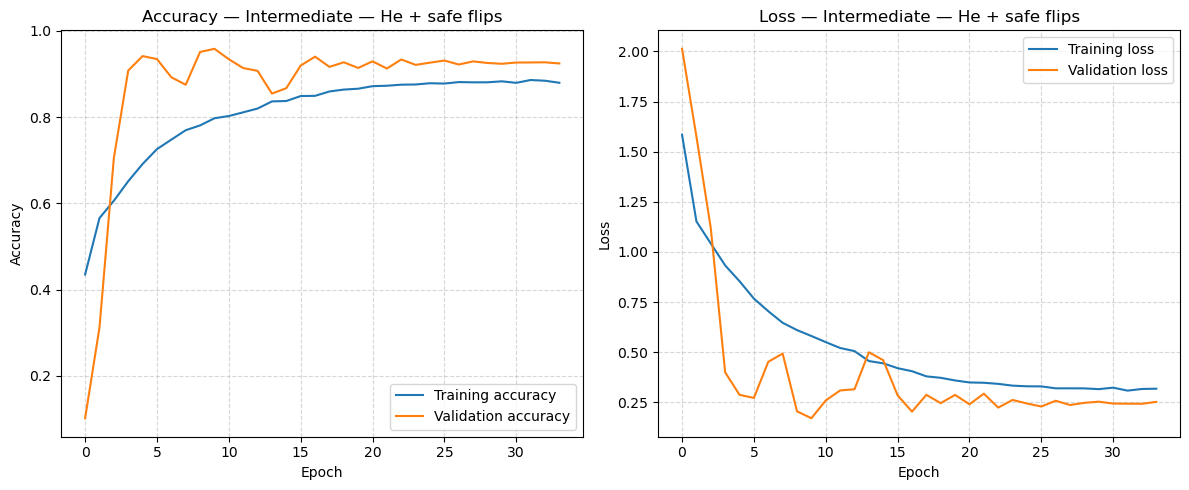

In [23]:
plot_training_history(
    history_safe_flip,
    safe_flip_name,
)

## Safe augmentation with L2 regularization

The regularized architecture combines He initialization, safe flips, and an L2 penalty on convolutional and dense kernels.

In [24]:
set_global_determinism(SEED)

regularized_name = "Intermediate — He + safe flips + L2"
regularized_checkpoint = (
    CHECKPOINT_DIR / "intermediate_he_safe_flips_l2.weights.h5"
)

model_regularized = build_intermediate_model(
    use_he=True,
    use_l2=True,
    optimizer="adam",
    input_shape=(*TARGET_SHAPE, 1),
    num_classes=num_classes,
)

safe_augmentation = ImageDataGenerator(
    horizontal_flip=True,
    vertical_flip=True,
)

history_regularized = model_regularized.fit(
    safe_augmentation.flow(
        X_train,
        y_train_categorical,
        batch_size=BATCH_SIZE,
        shuffle=True,
        seed=SEED,
    ),
    epochs=MAX_EPOCHS,
    validation_data=(X_validation, y_validation_categorical),
    callbacks=make_macro_f1_callbacks(
        X_validation,
        y_validation,
        regularized_checkpoint,
        batch_size=PREDICTION_BATCH_SIZE,
    ),
    verbose=1,
)

register_validation_result(
    regularized_name,
    model_regularized,
    history_regularized,
    regularized_checkpoint,
)

Epoch 1/50
122/125 [============================>.] - ETA: 0s - loss: 2.1171 - accuracy: 0.4292 — val_macro_f1: 0.0616 — val_balanced_accuracy: 0.2665
Saved new best Macro F1 checkpoint at epoch 1.
125/125 [==============================] - 4s 33ms/step - loss: 2.1080 - accuracy: 0.4309 - val_loss: 2.4283 - val_accuracy: 0.0578 - val_macro_f1: 0.0616 - val_balanced_accuracy: 0.2665 - lr: 0.0010
Epoch 2/50
125/125 [==============================] - ETA: 0s - loss: 1.5867 - accuracy: 0.5705 — val_macro_f1: 0.2458 — val_balanced_accuracy: 0.3888
Saved new best Macro F1 checkpoint at epoch 2.
125/125 [==============================] - 4s 31ms/step - loss: 1.5867 - accuracy: 0.5705 - val_loss: 2.0508 - val_accuracy: 0.1439 - val_macro_f1: 0.2458 - val_balanced_accuracy: 0.3888 - lr: 0.0010
Epoch 3/50
122/125 [============================>.] - ETA: 0s - loss: 1.4213 - accuracy: 0.6183 — val_macro_f1: 0.4422 — val_balanced_accuracy: 0.4460
Saved new best Macro F1 checkpoint at epoch 3.
125/12

,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1
Intermediate — He + safe flips + L2,95.54%,72.29%,75.84%,72.29%,73.57%


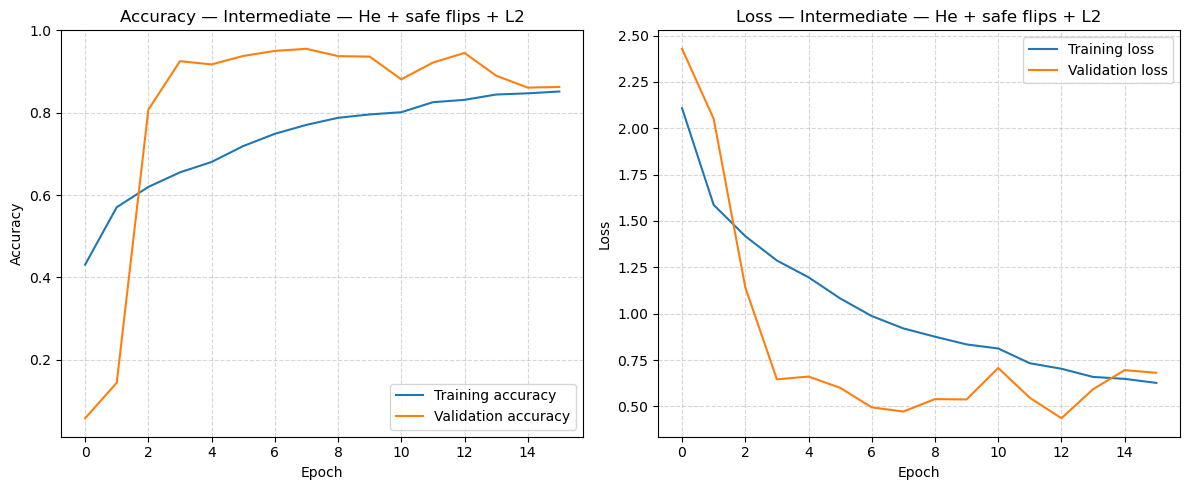

In [25]:
plot_training_history(
    history_regularized,
    regularized_name,
)

## Architecture comparison on validation data

Macro F1 is the primary comparison metric because each class contributes equally. Balanced accuracy is used as a secondary measure. Ordinary accuracy remains visible but is not used to choose a configuration.

,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1
Model,,,,,
Intermediate — Baseline,95.74%,81.31%,79.85%,81.31%,80.30%
Intermediate — He + safe flips,93.13%,85.25%,73.07%,85.25%,77.60%
Intermediate — He initialization,91.57%,82.48%,71.76%,82.48%,75.27%
Intermediate — He + safe flips + L2,95.54%,72.29%,75.84%,72.29%,73.57%
Intermediate — He + arbitrary rotations,87.25%,71.05%,70.86%,71.05%,65.79%


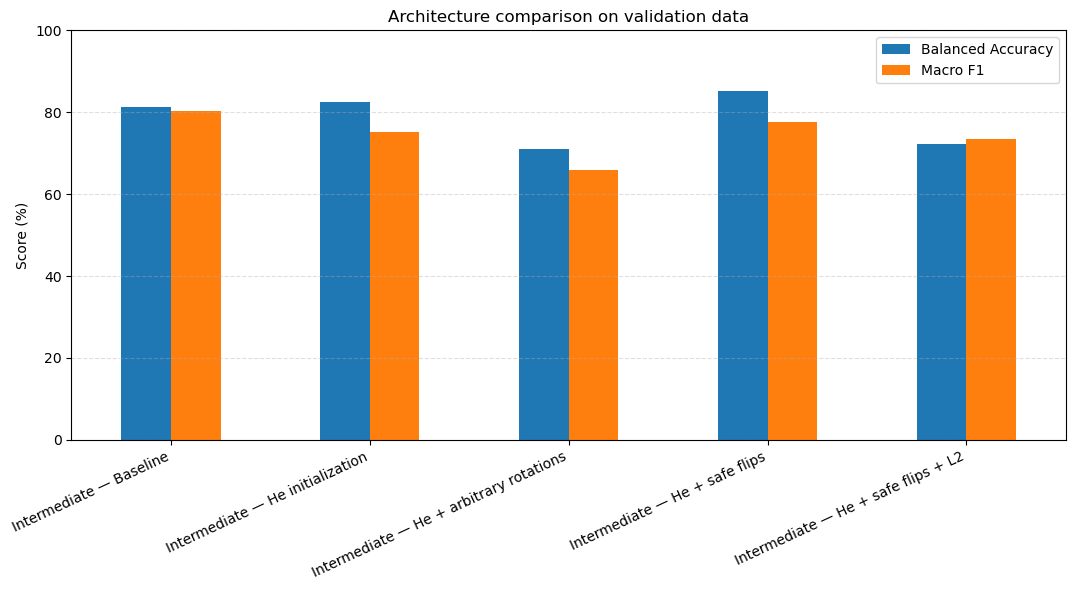

In [26]:
validation_df = (
    pd.DataFrame(validation_records)
    .set_index("Model")
    .sort_values(
        ["Macro F1", "Balanced Accuracy"],
        ascending=False,
    )
)

display(
    validation_df.style.format(
        {
            column: "{:.2%}"
            for column in validation_df.columns
        }
    )
)

architecture_names = [
    baseline_name,
    he_name,
    bad_rotation_name,
    safe_flip_name,
    regularized_name,
]
architecture_validation_df = validation_df.loc[
    architecture_names
]

axis = (
    architecture_validation_df[
        ["Balanced Accuracy", "Macro F1"]
    ]
    .mul(100)
    .plot(kind="bar", figsize=(11, 6))
)
axis.set_title("Architecture comparison on validation data")
axis.set_ylabel("Score (%)")
axis.set_xlabel("")
axis.set_ylim(0, 100)
axis.grid(axis="y", linestyle="--", alpha=0.4)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## Optimizer comparison

The optimizer study uses the same regularized intermediate architecture and safe augmentation for every run. Each optimizer receives a fresh model initialized from the same seed.

In [27]:
optimizer_factories = {
    "SGD + Nesterov": lambda: SGD(
        learning_rate=0.01,
        momentum=0.9,
        nesterov=True,
    ),
    "RMSprop": lambda: RMSprop(learning_rate=0.001),
    "Nadam": lambda: Nadam(learning_rate=0.001),
}

optimizer_model_names = [regularized_name]

optimizer_histories = {
    "Adam": history_regularized,
}

for optimizer_name, optimizer_factory in optimizer_factories.items():
    set_global_determinism(SEED)

    model_name = f"Intermediate optimizer — {optimizer_name}"
    safe_filename = (
        optimizer_name.lower()
        .replace(" + ", "_")
        .replace(" ", "_")
    )
    checkpoint_path = (
        CHECKPOINT_DIR
        / f"intermediate_optimizer_{safe_filename}.weights.h5"
    )

    model = build_intermediate_model(
        use_he=True,
        use_l2=True,
        optimizer=optimizer_factory(),
        input_shape=(*TARGET_SHAPE, 1),
        num_classes=num_classes,
    )

    safe_augmentation = ImageDataGenerator(
        horizontal_flip=True,
        vertical_flip=True,
    )

    history = model.fit(
        safe_augmentation.flow(
            X_train,
            y_train_categorical,
            batch_size=BATCH_SIZE,
            shuffle=True,
            seed=SEED,
        ),
        epochs=MAX_EPOCHS,
        validation_data=(
            X_validation,
            y_validation_categorical,
        ),
        callbacks=make_macro_f1_callbacks(
            X_validation,
            y_validation,
            checkpoint_path,
            batch_size=PREDICTION_BATCH_SIZE,
        ),
        verbose=1,
    )

    register_validation_result(
        model_name,
        model,
        history,
        checkpoint_path,
    )

    optimizer_model_names.append(model_name)
    optimizer_histories[optimizer_name] = history

Epoch 1/50
124/125 [============================>.] - ETA: 0s - loss: 2.2746 - accuracy: 0.3504 — val_macro_f1: 0.0270 — val_balanced_accuracy: 0.1827
Saved new best Macro F1 checkpoint at epoch 1.
125/125 [==============================] - 5s 34ms/step - loss: 2.2714 - accuracy: 0.3511 - val_loss: 2.7379 - val_accuracy: 0.0421 - val_macro_f1: 0.0270 - val_balanced_accuracy: 0.1827 - lr: 0.0100
Epoch 2/50
125/125 [==============================] - ETA: 0s - loss: 1.8365 - accuracy: 0.4709 — val_macro_f1: 0.1703 — val_balanced_accuracy: 0.3305
Saved new best Macro F1 checkpoint at epoch 2.
125/125 [==============================] - 4s 30ms/step - loss: 1.8365 - accuracy: 0.4709 - val_loss: 2.3531 - val_accuracy: 0.0937 - val_macro_f1: 0.1703 - val_balanced_accuracy: 0.3305 - lr: 0.0100
Epoch 3/50
122/125 [============================>.] - ETA: 0s - loss: 1.7104 - accuracy: 0.5172 — val_macro_f1: 0.3804 — val_balanced_accuracy: 0.5205
Saved new best Macro F1 checkpoint at epoch 3.
125/12

,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1
Intermediate optimizer — SGD + Nesterov,95.97%,90.58%,81.76%,90.58%,85.64%


Epoch 1/50
122/125 [============================>.] - ETA: 0s - loss: 2.2970 - accuracy: 0.4516 — val_macro_f1: 0.1212 — val_balanced_accuracy: 0.2759
Saved new best Macro F1 checkpoint at epoch 1.
125/125 [==============================] - 5s 32ms/step - loss: 2.2803 - accuracy: 0.4542 - val_loss: 3.0535 - val_accuracy: 0.0554 - val_macro_f1: 0.1212 - val_balanced_accuracy: 0.2759 - lr: 0.0010
Epoch 2/50
125/125 [==============================] - ETA: 0s - loss: 1.4513 - accuracy: 0.6276 — val_macro_f1: 0.3795 — val_balanced_accuracy: 0.4998
Saved new best Macro F1 checkpoint at epoch 2.
125/125 [==============================] - 4s 31ms/step - loss: 1.4513 - accuracy: 0.6276 - val_loss: 3.1734 - val_accuracy: 0.1954 - val_macro_f1: 0.3795 - val_balanced_accuracy: 0.4998 - lr: 0.0010
Epoch 3/50
125/125 [==============================] - ETA: 0s - loss: 1.1590 - accuracy: 0.7173 — val_macro_f1: 0.4567 — val_balanced_accuracy: 0.5678
Saved new best Macro F1 checkpoint at epoch 3.
125/12

,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1
Intermediate optimizer — RMSprop,95.68%,84.73%,80.61%,84.73%,82.15%


Epoch 1/50
125/125 [==============================] - ETA: 0s - loss: 1.9518 - accuracy: 0.4971 — val_macro_f1: 0.1250 — val_balanced_accuracy: 0.3525
Saved new best Macro F1 checkpoint at epoch 1.
125/125 [==============================] - 5s 35ms/step - loss: 1.9518 - accuracy: 0.4971 - val_loss: 2.8451 - val_accuracy: 0.0774 - val_macro_f1: 0.1250 - val_balanced_accuracy: 0.3525 - lr: 0.0010
Epoch 2/50
125/125 [==============================] - ETA: 0s - loss: 1.4496 - accuracy: 0.6303 — val_macro_f1: 0.3859 — val_balanced_accuracy: 0.5101
Saved new best Macro F1 checkpoint at epoch 2.
125/125 [==============================] - 4s 30ms/step - loss: 1.4496 - accuracy: 0.6303 - val_loss: 1.9707 - val_accuracy: 0.2445 - val_macro_f1: 0.3859 - val_balanced_accuracy: 0.5101 - lr: 0.0010
Epoch 3/50
125/125 [==============================] - ETA: 0s - loss: 1.2688 - accuracy: 0.6901 — val_macro_f1: 0.3919 — val_balanced_accuracy: 0.4645
Saved new best Macro F1 checkpoint at epoch 3.
125/12

,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1
Intermediate optimizer — Nadam,94.01%,88.56%,75.41%,88.56%,80.57%


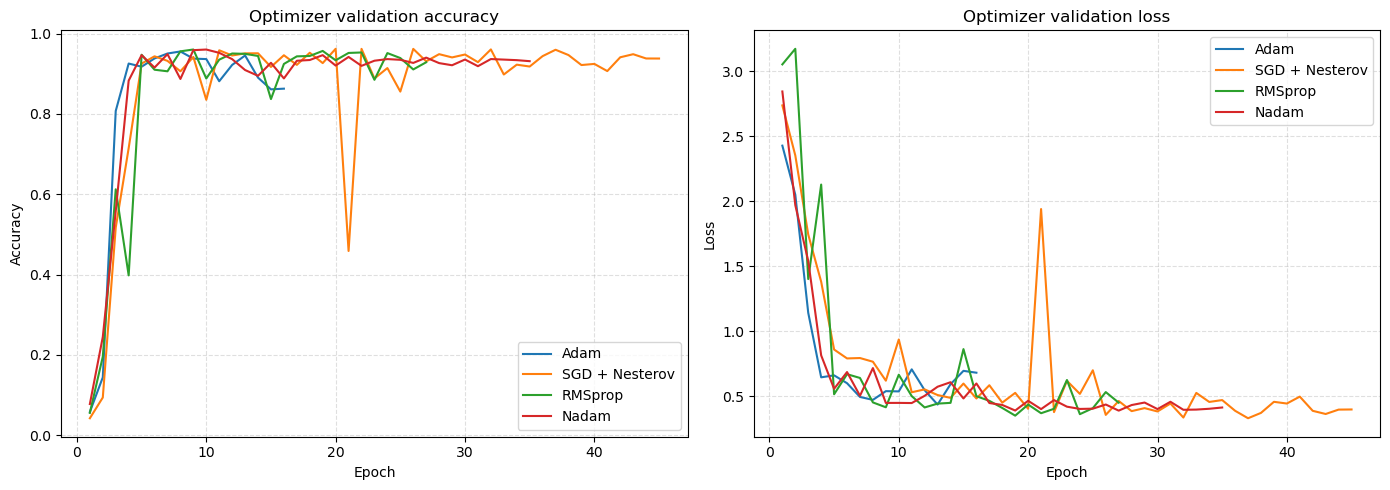

In [28]:
_, axes = plt.subplots(1, 2, figsize=(14, 5))

for optimizer_name, history in optimizer_histories.items():
    epochs = range(
        1,
        len(history.history["val_accuracy"]) + 1,
    )
    axes[0].plot(
        epochs,
        history.history["val_accuracy"],
        label=optimizer_name,
    )
    axes[1].plot(
        epochs,
        history.history["val_loss"],
        label=optimizer_name,
    )

axes[0].set_title("Optimizer validation accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")

axes[1].set_title("Optimizer validation loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")

for axis in axes:
    axis.legend()
    axis.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [29]:
validation_df = (
    pd.DataFrame(validation_records)
    .drop_duplicates(subset="Model", keep="last")
    .set_index("Model")
    .sort_values(
        ["Macro F1", "Balanced Accuracy"],
        ascending=False,
    )
)

optimizer_validation_df = validation_df.loc[
    optimizer_model_names
]
display(
    optimizer_validation_df.style.format(
        {
            column: "{:.2%}"
            for column in optimizer_validation_df.columns
        }
    )
)

selected_model_name = validation_df.index[0]
print(
    "Model selected from validation metrics: "
    f"{selected_model_name}"
)

,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1
Model,,,,,
Intermediate — He + safe flips + L2,95.54%,72.29%,75.84%,72.29%,73.57%
Intermediate optimizer — SGD + Nesterov,95.97%,90.58%,81.76%,90.58%,85.64%
Intermediate optimizer — RMSprop,95.68%,84.73%,80.61%,84.73%,82.15%
Intermediate optimizer — Nadam,94.01%,88.56%,75.41%,88.56%,80.57%


Model selected from validation metrics: Intermediate optimizer — SGD + Nesterov


## Final evaluation on the large test set

All configurations are now fixed. Every saved checkpoint is evaluated on the same uncapped 20% test partition.

These results must not be used to redesign or retrain the models. Any later tuning would require a new untouched test set.

In [30]:
test_records = []
test_reports = {}
test_confusion_matrices = {}
test_predictions = {}

for model_name, model in models.items():
    model.load_weights(checkpoints[model_name])

    metrics, report, matrix, predictions = evaluate_classifier(
        model,
        X_test,
        y_test,
        class_names,
        batch_size=PREDICTION_BATCH_SIZE,
    )

    test_records.append({"Model": model_name, **metrics})
    test_reports[model_name] = report
    test_confusion_matrices[model_name] = matrix
    test_predictions[model_name] = predictions

test_df = (
    pd.DataFrame(test_records)
    .set_index("Model")
    .loc[validation_df.index]
)

display(
    test_df.style.format(
        {
            column: "{:.2%}"
            for column in test_df.columns
        }
    )
)

,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1
Model,,,,,
Intermediate optimizer — SGD + Nesterov,95.80%,85.33%,81.03%,85.33%,82.29%
Intermediate optimizer — RMSprop,95.58%,80.70%,80.15%,80.70%,79.67%
Intermediate optimizer — Nadam,93.89%,85.37%,75.43%,85.37%,79.03%
Intermediate — Baseline,95.55%,76.97%,79.01%,76.97%,77.21%
Intermediate — He + safe flips,93.16%,82.64%,71.31%,82.64%,75.53%
Intermediate — He initialization,91.09%,78.55%,70.38%,78.55%,72.64%
Intermediate — He + safe flips + L2,95.41%,67.64%,74.63%,67.64%,69.89%
Intermediate — He + arbitrary rotations,87.32%,69.87%,70.12%,69.87%,64.77%


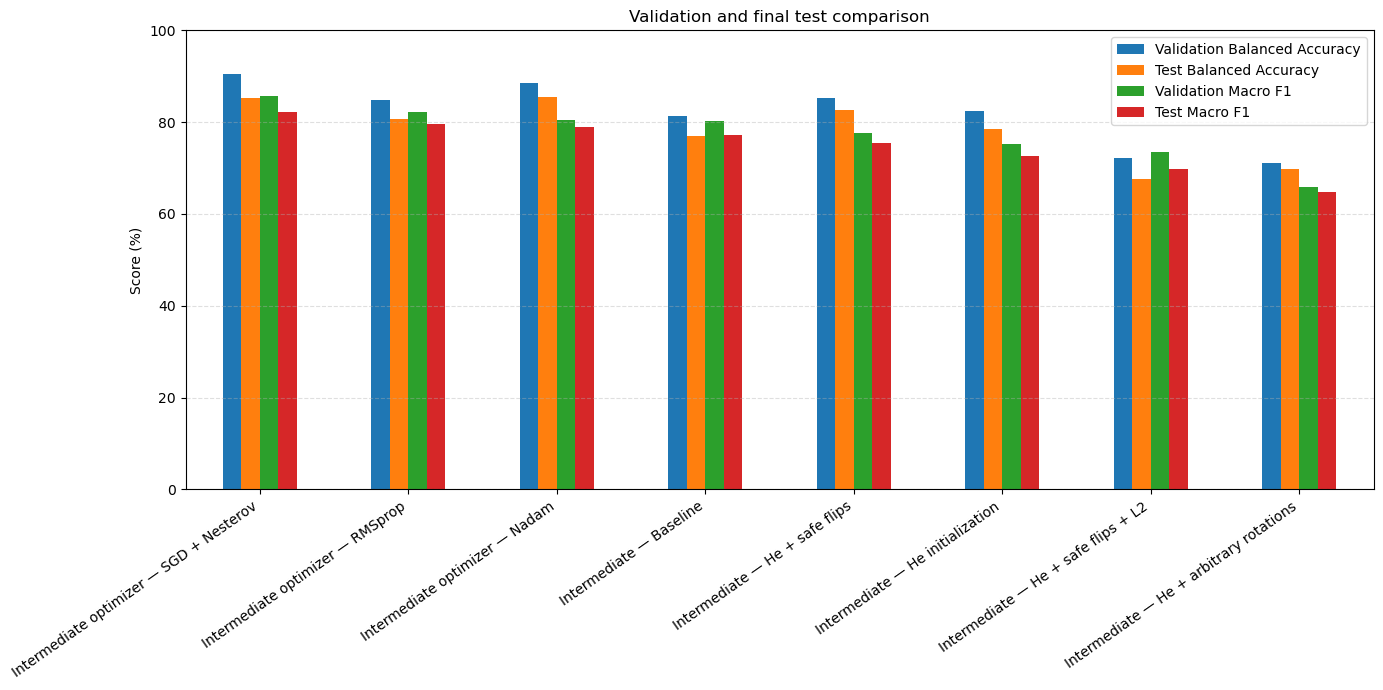

In [31]:
comparison = pd.concat(
    {
        "Validation Balanced Accuracy": (
            validation_df["Balanced Accuracy"]
        ),
        "Test Balanced Accuracy": (
            test_df["Balanced Accuracy"]
        ),
        "Validation Macro F1": validation_df["Macro F1"],
        "Test Macro F1": test_df["Macro F1"],
    },
    axis=1,
)

axis = comparison.mul(100).plot(
    kind="bar",
    figsize=(14, 7),
)
axis.set_title("Validation and final test comparison")
axis.set_ylabel("Score (%)")
axis.set_xlabel("")
axis.set_ylim(0, 100)
axis.grid(axis="y", linestyle="--", alpha=0.4)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

## Detailed report for the validation-selected model

The detailed test report is shown for the model chosen before opening the test results.

Validation-selected model: Intermediate optimizer — SGD + Nesterov


,precision,recall,f1-score,support
center,0.800,0.966,0.875,859
donut,0.876,0.829,0.852,111
edge-loc,0.671,0.867,0.756,1038
edge-ring,0.951,0.978,0.965,1936
loc,0.599,0.781,0.678,718
near-full,1.000,0.667,0.800,30
none,0.994,0.967,0.980,29486
random,0.731,0.942,0.823,173
scratch,0.671,0.682,0.676,239
accuracy,0.958,0.958,0.958,1


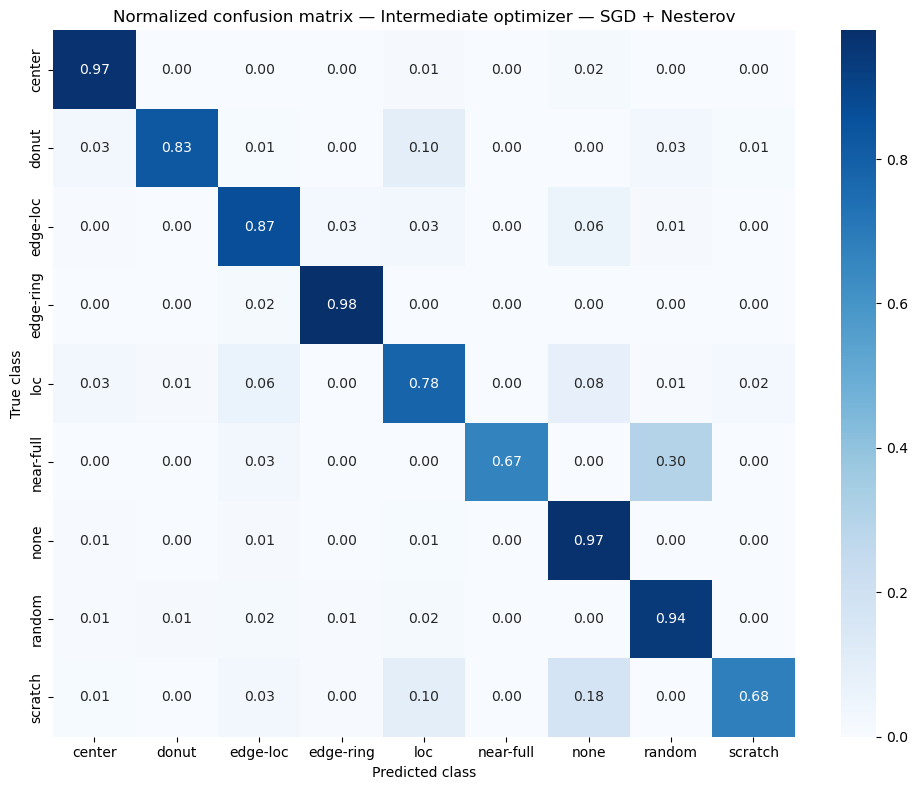

In [32]:
print(f"Validation-selected model: {selected_model_name}")

display(
    test_reports[selected_model_name]
    .loc[
        list(class_names)
        + ["accuracy", "macro avg", "weighted avg"]
    ]
    .style.format(
        {
            "precision": "{:.3f}",
            "recall": "{:.3f}",
            "f1-score": "{:.3f}",
            "support": "{:.0f}",
        }
    )
)

plot_confusion_matrix(
    test_confusion_matrices[selected_model_name],
    class_names,
    title=(
        "Normalized confusion matrix — "
        f"{selected_model_name}"
    ),
    normalize=True,
)

## Feature-map inspection

The selected model is inspected on one example from the untouched test partition after final evaluation.

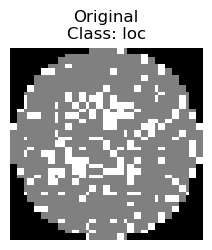

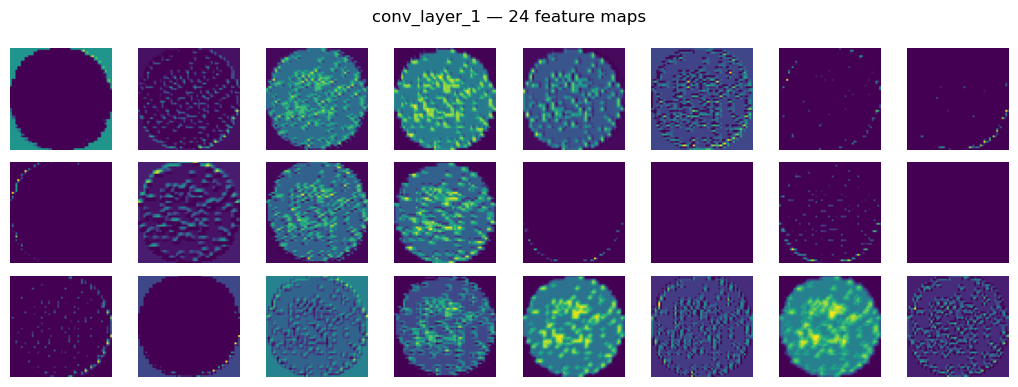

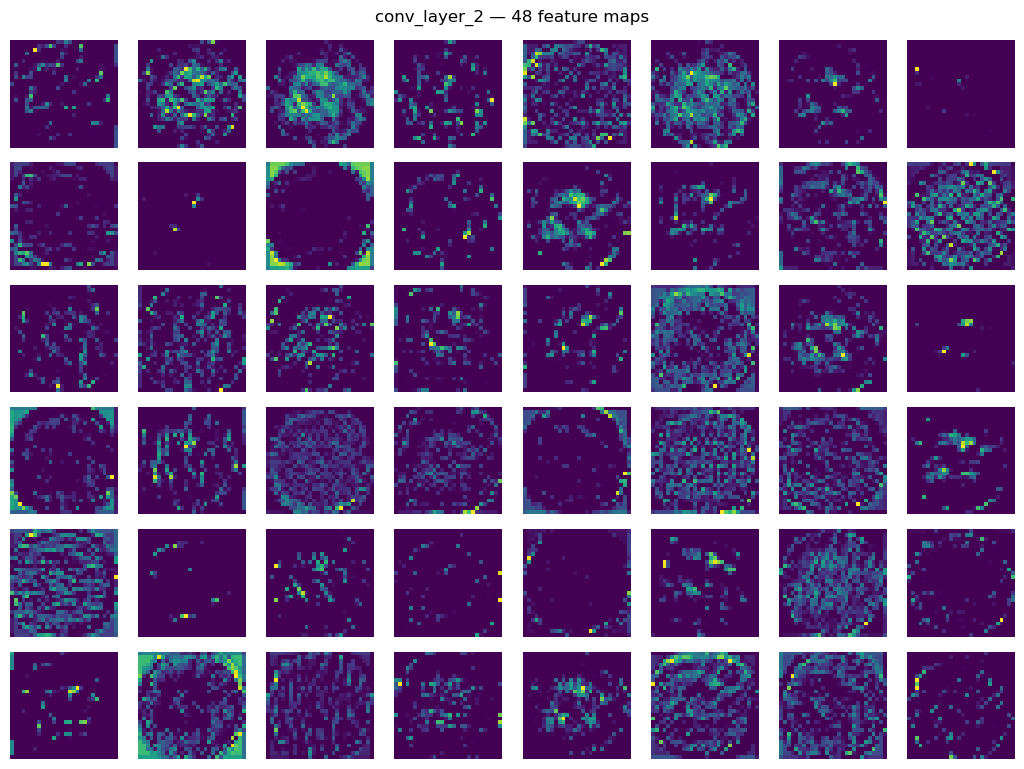

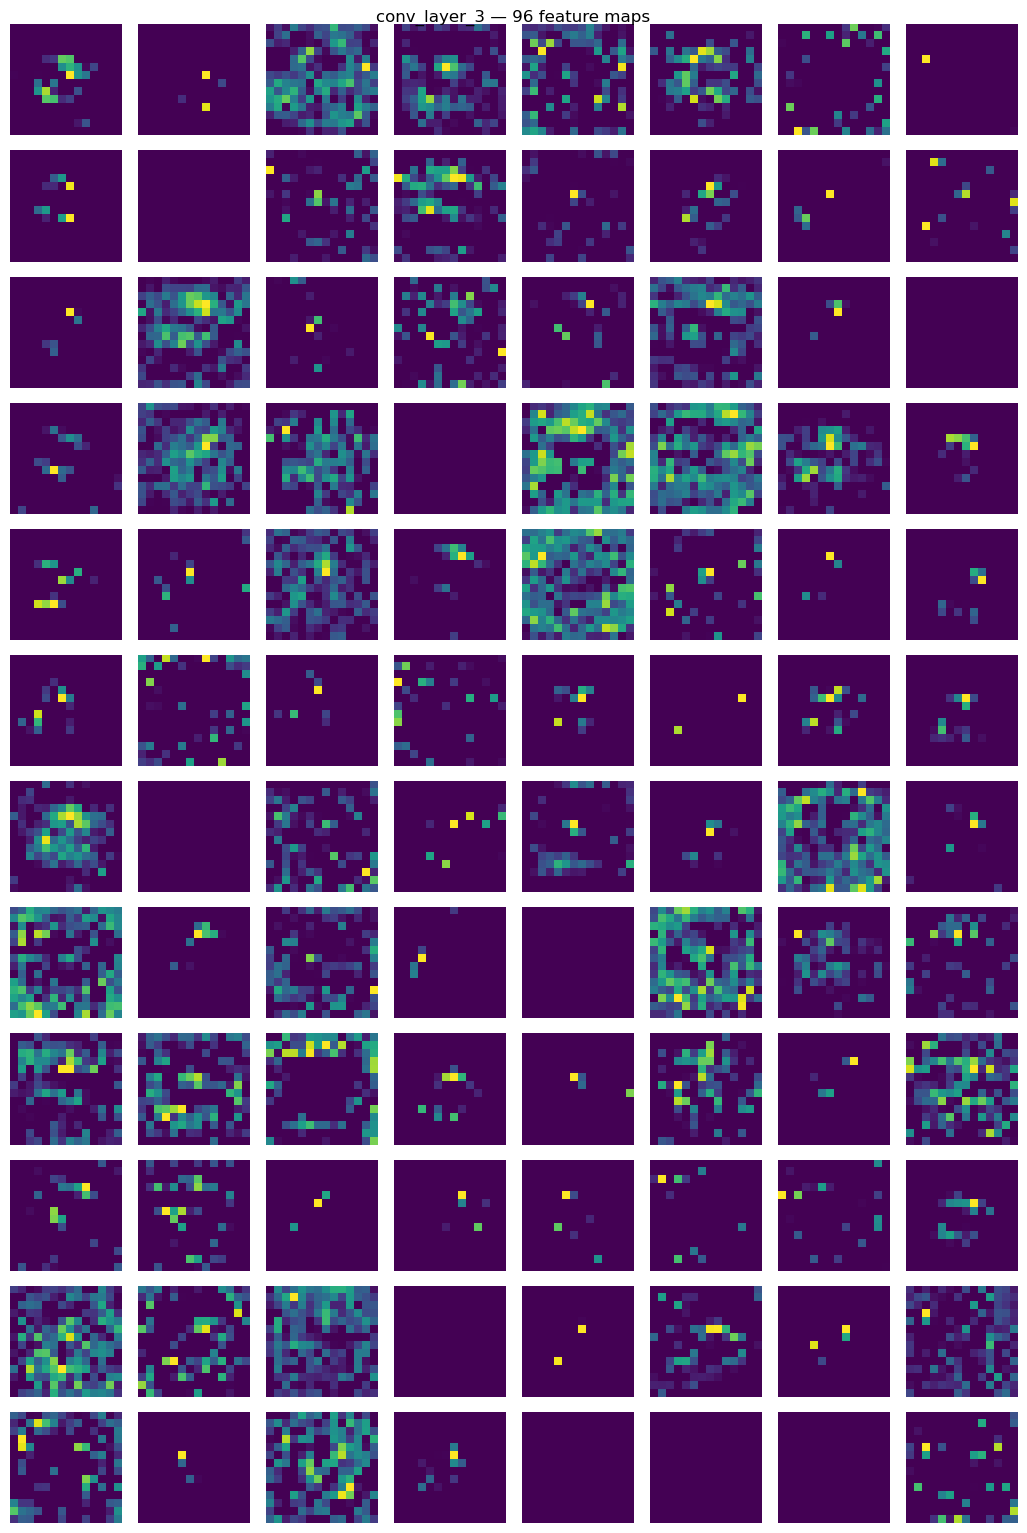

In [41]:
sample_index = 300

visualize_original_and_maps(
    models[selected_model_name],
    X_test[sample_index],
    int(y_test[sample_index]),
    class_names,
)

## Saved outputs

The split indices make the exact data partition reproducible. Validation and test tables are exported for direct use in the report.

In [34]:
architecture_metadata = pd.DataFrame(
    {
        "Architecture": ["Intermediate CNN"],
        "Convolutional filters": ["24, 48, 96"],
        "Dense units": [96],
        "Parameters": [intermediate_parameter_count],
        "Reference full parameters": [full_parameter_count],
        "Parameter reduction (%)": [parameter_reduction],
        "Batch size": [BATCH_SIZE],
        "Seed": [SEED],
    }
)

validation_df.to_csv(
    OUTPUT_DIR / "validation_results.csv"
)
test_df.to_csv(
    OUTPUT_DIR / "large_test_results.csv"
)
split_distribution.to_csv(
    OUTPUT_DIR / "split_distribution.csv"
)
architecture_metadata.to_csv(
    OUTPUT_DIR / "architecture_metadata.csv",
    index=False,
)

print(f"Saved outputs under: {OUTPUT_DIR.resolve()}")

Saved outputs under: C:\Users\lollo\Documents\GitHub\deep-learning-wafer-defects\project\cnn_outputs_intermediate


## Technical consistency audit

This section verifies the dataset, data partitions, model complexity, and checkpoint mapping used in this notebook.

In [35]:
import hashlib
import json
from pathlib import Path

MODEL_FAMILY = "INTERMEDIATE"

EXPECTED_OUTPUT_DIR = (
    PROJECT_DIR / "cnn_outputs_intermediate"
).resolve()

ACTUAL_OUTPUT_DIR = Path(OUTPUT_DIR).resolve()

if ACTUAL_OUTPUT_DIR != EXPECTED_OUTPUT_DIR:
    raise ValueError(
        "The INTERMEDIATE notebook must use "
        "OUTPUT_DIR = PROJECT_DIR / "
        "'cnn_outputs_intermediate'.\n"
        f"Current output directory: {ACTUAL_OUTPUT_DIR}"
    )

AUDIT_DIR = OUTPUT_DIR / "audit"
AUDIT_DIR.mkdir(parents=True, exist_ok=True)


def repository_relative_path(path):
    return (
        Path(path)
        .resolve()
        .relative_to(REPO_ROOT.resolve())
        .as_posix()
    )


def sha256_array(array):
    array = np.ascontiguousarray(array)

    digest = hashlib.sha256()
    digest.update(str(array.dtype).encode("utf-8"))
    digest.update(str(array.shape).encode("utf-8"))
    digest.update(array.tobytes())

    return digest.hexdigest()


def sha256_file(path, chunk_size=8 * 1024 * 1024):
    path = Path(path)

    if not path.exists():
        return None

    digest = hashlib.sha256()

    with path.open("rb") as file:
        while True:
            chunk = file.read(chunk_size)

            if not chunk:
                break

            digest.update(chunk)

    return digest.hexdigest()


def count_weight_parameters(weights):
    return int(
        sum(np.prod(weight.shape) for weight in weights)
    )


def architecture_signature(model):
    convolution_filters = [
        int(layer.filters)
        for layer in model.layers
        if isinstance(layer, tf.keras.layers.Conv2D)
    ]

    dense_units = [
        int(layer.units)
        for layer in model.layers
        if isinstance(layer, tf.keras.layers.Dense)
    ]

    return {
        "convolution_filters": convolution_filters,
        "dense_units": dense_units,
        "total_parameters": int(model.count_params()),
        "trainable_parameters": count_weight_parameters(
            model.trainable_weights
        ),
        "non_trainable_parameters": count_weight_parameters(
            model.non_trainable_weights
        ),
    }


complexity_records = []

for model_name, model in models.items():
    signature = architecture_signature(model)

    complexity_records.append(
        {
            "Model": model_name,
            "Conv filters": str(
                signature["convolution_filters"]
            ),
            "Dense units": str(
                signature["dense_units"]
            ),
            "Total parameters": (
                signature["total_parameters"]
            ),
            "Trainable parameters": (
                signature["trainable_parameters"]
            ),
            "Non-trainable parameters": (
                signature["non_trainable_parameters"]
            ),
        }
    )

complexity_df = (
    pd.DataFrame(complexity_records)
    .set_index("Model")
    .sort_values("Total parameters")
)

display(complexity_df)

,Conv filters,Dense units,Total parameters,Trainable parameters,Non-trainable parameters
Model,,,,,
Intermediate — Baseline,"[24, 48, 96]","[96, 9]",505449,505113,336
Intermediate — He initialization,"[24, 48, 96]","[96, 9]",505449,505113,336
Intermediate — He + arbitrary rotations,"[24, 48, 96]","[96, 9]",505449,505113,336
Intermediate — He + safe flips,"[24, 48, 96]","[96, 9]",505449,505113,336
Intermediate — He + safe flips + L2,"[24, 48, 96]","[96, 9]",505449,505113,336
Intermediate optimizer — SGD + Nesterov,"[24, 48, 96]","[96, 9]",505449,505113,336
Intermediate optimizer — RMSprop,"[24, 48, 96]","[96, 9]",505449,505113,336
Intermediate optimizer — Nadam,"[24, 48, 96]","[96, 9]",505449,505113,336


In [ ]:
checkpoint_records = []

for model_name, checkpoint_path in checkpoints.items():
    checkpoint_path = Path(checkpoint_path)

    checkpoint_records.append(
        {
            "Model": model_name,
            "Checkpoint": str(checkpoint_path),
            "Repository path": repository_relative_path(
                checkpoint_path
            ),
            "Exists": checkpoint_path.exists(),
            "Size (MB)": (
                checkpoint_path.stat().st_size / (1024 * 1024)
                if checkpoint_path.exists()
                else np.nan
            ),
            "SHA256": sha256_file(checkpoint_path),
        }
    )

checkpoint_audit_df = (
    pd.DataFrame(checkpoint_records)
    .set_index("Model")
)

if not checkpoint_audit_df["Exists"].all():
    missing_checkpoints = checkpoint_audit_df.loc[
        ~checkpoint_audit_df["Exists"],
        ["Checkpoint"],
    ]

    raise FileNotFoundError(
        "Some checkpoints are missing:\n"
        f"{missing_checkpoints}"
    )

duplicated_paths = checkpoint_audit_df[
    checkpoint_audit_df["Repository path"].duplicated(
        keep=False
    )
]

if not duplicated_paths.empty:
    raise AssertionError(
        "Multiple models point to the same checkpoint path:\n"
        f"{duplicated_paths[['Repository path']]}"
    )

print("All INTERMEDIATE checkpoint files exist.")
print("Every INTERMEDIATE model uses a distinct checkpoint path.")

,Checkpoint,Repository path,Exists,Size (MB),SHA256
Model,,,,,
Intermediate — Baseline,C:\Users\lollo\Documents\GitHub\deep-learning-...,project/cnn_outputs_intermediate/checkpoints/i...,True,1.963951,2c8f7afc5997e12c02060386c41022d0e24cc55b6c99fe...
Intermediate — He initialization,C:\Users\lollo\Documents\GitHub\deep-learning-...,project/cnn_outputs_intermediate/checkpoints/i...,True,1.963951,203454b8ca0aefc8c7dbc9ab92b3be4143e640be20e1c3...
Intermediate — He + arbitrary rotations,C:\Users\lollo\Documents\GitHub\deep-learning-...,project/cnn_outputs_intermediate/checkpoints/i...,True,1.963951,8724c1ddbe08e63b7cf99ae95368ec115837c7fc2ab600...
Intermediate — He + safe flips,C:\Users\lollo\Documents\GitHub\deep-learning-...,project/cnn_outputs_intermediate/checkpoints/i...,True,1.963951,6ee045148b98b566581fdceeafebc9098cafc13c07bfc6...
Intermediate — He + safe flips + L2,C:\Users\lollo\Documents\GitHub\deep-learning-...,project/cnn_outputs_intermediate/checkpoints/i...,True,1.963951,cb256900c15d452d33641c30a48c25cbe51e3ef75cedb0...
Intermediate optimizer — SGD + Nesterov,C:\Users\lollo\Documents\GitHub\deep-learning-...,project/cnn_outputs_intermediate/checkpoints/i...,True,1.963951,1ce0a1d6b3c22096e88f0b7ff3e41b8a8ee12e389efe02...
Intermediate optimizer — RMSprop,C:\Users\lollo\Documents\GitHub\deep-learning-...,project/cnn_outputs_intermediate/checkpoints/i...,True,1.963951,12a6395a36dace008ad282f7deef0924cfd1ac3ed84dfc...
Intermediate optimizer — Nadam,C:\Users\lollo\Documents\GitHub\deep-learning-...,project/cnn_outputs_intermediate/checkpoints/i...,True,1.963951,eb28d72e6bb61e03b145741d8d80b9771411f43b1bcbed...


All INTERMEDIATE checkpoint files exist.
Every INTERMEDIATE model uses a distinct checkpoint path.


In [37]:
dataset_path = Path(DATASET_PATH)

selected_signature = architecture_signature(
    models[selected_model_name]
)

audit_data = {
    "model_family": MODEL_FAMILY,
    "dataset": {
        "path": repository_relative_path(dataset_path),
        "exists": dataset_path.exists(),
        "sha256": sha256_file(dataset_path),
        "number_of_rows": int(len(df)),
    },
    "splits": {
        "train": {
            "size": int(len(train_indices)),
            "sha256": sha256_array(train_indices),
        },
        "validation": {
            "size": int(len(validation_indices)),
            "sha256": sha256_array(validation_indices),
        },
        "test": {
            "size": int(len(test_indices)),
            "sha256": sha256_array(test_indices),
        },
    },
    "selected_model": {
        "name": selected_model_name,
        **selected_signature,
        "validation_metrics": {
            metric: float(value)
            for metric, value in validation_df.loc[
                selected_model_name
            ].items()
        },
        "test_metrics": {
            metric: float(value)
            for metric, value in test_df.loc[
                selected_model_name
            ].items()
        },
    },
    "checkpoint_paths_are_unique": bool(
        checkpoint_audit_df["Repository path"].is_unique
    ),
}

audit_path = AUDIT_DIR / "intermediate_audit.json"

with audit_path.open("w", encoding="utf-8") as file:
    json.dump(audit_data, file, indent=2)

complexity_df.to_csv(
    AUDIT_DIR / "intermediate_complexity.csv"
)

checkpoint_audit_df.to_csv(
    AUDIT_DIR / "intermediate_checkpoints.csv"
)

print(f"INTERMEDIATE audit saved to: {audit_path.resolve()}")

INTERMEDIATE audit saved to: C:\Users\lollo\Documents\GitHub\deep-learning-wafer-defects\project\cnn_outputs_intermediate\audit\intermediate_audit.json


In [38]:
checkpoint_verification_records = []

for model_name in test_df.index:
    model = models[model_name]
    checkpoint_path = checkpoints[model_name]

    model.load_weights(checkpoint_path)

    recalculated_metrics, _, _, _ = evaluate_classifier(
        model,
        X_test,
        y_test,
        class_names,
        batch_size=PREDICTION_BATCH_SIZE,
    )

    record = {"Model": model_name}

    for metric_name, recalculated_value in (
        recalculated_metrics.items()
    ):
        stored_value = float(
            test_df.loc[model_name, metric_name]
        )

        record[f"{metric_name} difference"] = abs(
            recalculated_value - stored_value
        )

    checkpoint_verification_records.append(record)

checkpoint_verification_df = (
    pd.DataFrame(checkpoint_verification_records)
    .set_index("Model")
)

display(
    checkpoint_verification_df.style.format(
        "{:.12f}"
    )
)

maximum_difference = float(
    checkpoint_verification_df.to_numpy().max()
)

print(
    "Maximum difference between stored and "
    f"recalculated metrics: {maximum_difference:.12f}"
)

if maximum_difference > 1e-8:
    raise AssertionError(
        "The INTERMEDIATE test table does not match "
        "the current checkpoint files."
    )

print(
    "The INTERMEDIATE test table matches the "
    "current checkpoint files."
)

,Accuracy difference,Balanced Accuracy difference,Macro Precision difference,Macro Recall difference,Macro F1 difference
Model,,,,,
Intermediate optimizer — SGD + Nesterov,0.000000000000,0.000000000000,0.000000000000,0.000000000000,0.000000000000
Intermediate optimizer — RMSprop,0.000000000000,0.000000000000,0.000000000000,0.000000000000,0.000000000000
Intermediate optimizer — Nadam,0.000000000000,0.000000000000,0.000000000000,0.000000000000,0.000000000000
Intermediate — Baseline,0.000000000000,0.000000000000,0.000000000000,0.000000000000,0.000000000000
Intermediate — He + safe flips,0.000000000000,0.000000000000,0.000000000000,0.000000000000,0.000000000000
Intermediate — He initialization,0.000000000000,0.000000000000,0.000000000000,0.000000000000,0.000000000000
Intermediate — He + safe flips + L2,0.000000000000,0.000000000000,0.000000000000,0.000000000000,0.000000000000
Intermediate — He + arbitrary rotations,0.000000000000,0.000000000000,0.000000000000,0.000000000000,0.000000000000


Maximum difference between stored and recalculated metrics: 0.000000000000
The INTERMEDIATE test table matches the current checkpoint files.
